# Despesa por ação/programa

Dados retirados do portaldatransparencia.gov.br, cada csv ano a ano foi armazenado em uma pasta, ultilizamos a biblioteca Glob para percorrer essa pasta e juntar em 1 so csv

In [31]:
import pandas as pd
import glob

caminho = "despesasporprograma/*.csv"

arquivos = glob.glob(caminho)

df_programa = pd.concat([
    pd.read_csv(arq, sep=";", encoding="latin1", on_bad_lines="skip")
    for arq in arquivos
], ignore_index=True)

In [32]:
df_programa.head()

,"ï»¿""MÃªs Ano""",Programa OrÃ§amentÃ¡rio,AÃ§Ã£o OrÃ§amentÃ¡ria,ÃrgÃ£o/Entidade Vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos,Unnamed: 8,"mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago"
0,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,"09HB - CONTRIBUICAO DA UNIAO, DE SUAS AUTARQUI...",20203 - AgÃªncia Nacional do Cinema,"14.765.335,00","1.101.818,64","1.101.818,64",NaN,NaN,NaN
1,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,0181 - APOSENTADORIAS E PENSOES CIVIS DA UNIAO,20203 - AgÃªncia Nacional do Cinema,"1.139.983,00","125.848,51","0,00",NaN,NaN,NaN
2,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,212B - BENEFICIOS OBRIGATORIOS AOS SERVIDORES ...,20203 - AgÃªncia Nacional do Cinema,"2.323.826,00","185.660,09","0,00",NaN,NaN,NaN
3,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2004 - ASSISTENCIA MEDICA E ODONTOLOGICA AOS S...,20203 - AgÃªncia Nacional do Cinema,"561.117,00","44.831,94","0,00",NaN,NaN,NaN
4,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2000 - ADMINISTRACAO DA UNIDADE,20203 - AgÃªncia Nacional do Cinema,"89.526,81","59.826,83","11.990,30",NaN,NaN,NaN


## Limpeza

Corrigindo os nome que tiveram problemas na acentuação

In [33]:
df_programa = df_programa.rename(columns={
    'ï»¿"MÃªs Ano"': "mes_ano",
    "Programa OrÃ§amentÃ¡rio": "programa_orcamentario",
    "AÃ§Ã£o OrÃ§amentÃ¡ria": "acao_orcamentaria",
    "ÃrgÃ£o/Entidade Vinculada": "orgao_entidade_vinculada",
})

df_programa.head()

,mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos,Unnamed: 8,"mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago"
0,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,"09HB - CONTRIBUICAO DA UNIAO, DE SUAS AUTARQUI...",20203 - AgÃªncia Nacional do Cinema,"14.765.335,00","1.101.818,64","1.101.818,64",NaN,NaN,NaN
1,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,0181 - APOSENTADORIAS E PENSOES CIVIS DA UNIAO,20203 - AgÃªncia Nacional do Cinema,"1.139.983,00","125.848,51","0,00",NaN,NaN,NaN
2,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,212B - BENEFICIOS OBRIGATORIOS AOS SERVIDORES ...,20203 - AgÃªncia Nacional do Cinema,"2.323.826,00","185.660,09","0,00",NaN,NaN,NaN
3,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2004 - ASSISTENCIA MEDICA E ODONTOLOGICA AOS S...,20203 - AgÃªncia Nacional do Cinema,"561.117,00","44.831,94","0,00",NaN,NaN,NaN
4,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2000 - ADMINISTRACAO DA UNIDADE,20203 - AgÃªncia Nacional do Cinema,"89.526,81","59.826,83","11.990,30",NaN,NaN,NaN


Apagando colunas vazias que se criaram apos juntar os csvs

In [ ]:
df_programa = df_programa.drop(['Valor Restos a Pagar Pagos', 'Unnamed: 8', 'mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago'], axis=1)

df_programa.head()

KeyError: "['mes_ano', 'programa_orcamentario', 'acao_orcamentaria', 'orgao_entidade_vinculada', 'Valor Empenhado', 'Valor Liquidado', 'Valor Pago', 'Valor Restos a Pagar Pagos', 'Unnamed: 8', 'mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago'] not found in axis"

## Padronizar valores numericos

In [ ]:
df_programa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3588 entries, 0 to 3587
Data columns (total 9 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   mes_ano                                                                                                              1794 non-null   object 
 1   programa_orcamentario                                                                                                1794 non-null   object 
 2   acao_orcamentaria                                                                                                    1794 non-null   object 
 3   orgao_entidade_vinculada                                                                                             1794 non-null   object 
 4   Valor Empenha

Eliminando a coluna Valor Restos a Pagar Pagos pois é nula

In [ ]:
df_programa = df_programa.drop("Valor Restos a Pagar Pagos", axis=1)

df_programa.head()

,mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,"mes_ano,programa_orcamentario,acao_orcamentaria,orgao_entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago"
0,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,"09HB - CONTRIBUICAO DA UNIAO, DE SUAS AUTARQUI...",20203 - AgÃªncia Nacional do Cinema,"14.765.335,00","1.101.818,64","1.101.818,64",NaN
1,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,0181 - APOSENTADORIAS E PENSOES CIVIS DA UNIAO,20203 - AgÃªncia Nacional do Cinema,"1.139.983,00","125.848,51","0,00",NaN
2,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,212B - BENEFICIOS OBRIGATORIOS AOS SERVIDORES ...,20203 - AgÃªncia Nacional do Cinema,"2.323.826,00","185.660,09","0,00",NaN
3,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2004 - ASSISTENCIA MEDICA E ODONTOLOGICA AOS S...,20203 - AgÃªncia Nacional do Cinema,"561.117,00","44.831,94","0,00",NaN
4,01/2022,0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODE...,2000 - ADMINISTRACAO DA UNIDADE,20203 - AgÃªncia Nacional do Cinema,"89.526,81","59.826,83","11.990,30",NaN


Depois da 4 coluna, que são valores monetários, transformando cada uma para float, modificando a estrutura Brasileira de leitura para se adequar a estrutura do tipo float

In [ ]:
valores_colunas = df_programa.columns[4:]  

for col in valores_colunas:
    df_programa[col] = (
        df_programa[col]
        .astype(str)
        .str.strip()                     
        .str.replace("R$", "", regex=False)  
        .str.replace(" ", "", regex=False)  
        .str.replace(".", "", regex=False)  
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df_programa.head()

ValueError: could not convert string to float: '2022-01-01.0032-PROGRAMADEGESTAOEMANUTENCAODOPODEREXECUTIVO."09HB-CONTRIBUICAODAUNIAO.DESUASAUTARQUIASEFUNDACOESPARAOCUSTEIODOREGIMEDEPREVIDENCIADOSSERVIDORESPUBLICOSFEDERAIS".20203-AgÃªnciaNacionaldoCinema.147653350.110181864.110181864'

## Padronizando data

In [ ]:
print(df_programa["mes_ano"].unique())

['01/2022' '02/2022' '03/2022' '04/2022' '05/2022' '06/2022' '07/2022'
 '08/2022' '09/2022' '10/2022' '11/2022' '12/2022' '01/2026' '02/2026'
 '03/2026' '04/2026' '01/2025' '02/2025' '03/2025' '04/2025' '05/2025'
 '06/2025' '07/2025' '08/2025' '09/2025' '10/2025' '11/2025' '12/2025'
 '01/2024' '02/2024' '03/2024' '04/2024' '05/2024' '06/2024' '07/2024'
 '08/2024' '09/2024' '10/2024' '11/2024' '12/2024' '01/2021' '02/2021'
 '03/2021' '04/2021' '05/2021' '06/2021' '07/2021' '08/2021' '09/2021'
 '10/2021' '11/2021' '12/2021' '01/2020' '02/2020' '03/2020' '04/2020'
 '05/2020' '06/2020' '07/2020' '08/2020' '09/2020' '10/2020' '11/2020'
 '12/2020' '01/2019' '02/2019' '03/2019' '04/2019' '05/2019' '06/2019'
 '07/2019' '08/2019' '09/2019' '10/2019' '11/2019' '12/2019' '01/2018'
 '02/2018' '03/2018' '04/2018' '05/2018' '06/2018' '07/2018' '08/2018'
 '09/2018' '10/2018' '11/2018' '12/2018' '01/2017' '02/2017' '03/2017'
 '04/2017' '05/2017' '06/2017' '07/2017' '08/2017' '09/2017' '10/2017'
 '11/2

transformação padrão para valores de data usando o tipo datetime do pandas

In [ ]:
df_programa["mes_ano"] = pd.to_datetime(df_programa["mes_ano"], format="%m/%Y")

In [ ]:
df_programa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1794 entries, 0 to 1793
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   mes_ano                   1794 non-null   datetime64[ns]
 1   programa_orcamentario     1794 non-null   object        
 2   acao_orcamentaria         1794 non-null   object        
 3   orgao_entidade_vinculada  1794 non-null   object        
 4   Valor Empenhado           1794 non-null   float64       
 5   Valor Liquidado           1794 non-null   float64       
 6   Valor Pago                1794 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 98.2+ KB


In [ ]:
df_programa["programa_orcamentario"].unique()

## Padronizando textos

In [ ]:
def corrigir_encoding(texto):
    try:
        return texto.encode('latin1').decode('utf-8')
    except:
        return texto

colunas = ["programa_orcamentario", "orgao_entidade_vinculada", "acao_orcamentaria"]

for col in colunas:
    df_programa[col] = df_programa[col].astype(str).apply(corrigir_encoding)

In [ ]:
df_programa["programa_orcamentario"].unique()

array(['0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODER EXECUTIVO',
       '5025 - CULTURA',
       '0910 - OPERACOES ESPECIAIS: GESTAO DA PARTICIPACAO EM ORGANISMOS E ENTIDADES NACIONAIS E INTERNACIONAIS',
       '2027 - CULTURA: DIMENSAO ESSENCIAL DO DESENVOLVIMENTO',
       '5125 - DIREITO A CULTURA',
       '2122 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA CIDADANIA',
       '2107 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA CULTURA',
       '0089 - PREVIDENCIA DE INATIVOS E PENSIONISTAS DA UNIAO',
       '2082 - POLITICA EXTERNA', '0169 - BRASIL, SOM E IMAGEM',
       '2115 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA SAUDE',
       '4005 - PROTECAO JURIDICA DA UNIAO'], dtype=object)

In [ ]:
df_programa.to_csv("despesasporprograma/execucao_programa.csv", index=False, encoding="utf-8")

## Como estão distribuidos os investimentos dentro da ancine?

In [ ]:
df_programa["programa_orcamentario"].unique()

array(['0032 - PROGRAMA DE GESTAO E MANUTENCAO DO PODER EXECUTIVO',
       '5025 - CULTURA',
       '0910 - OPERACOES ESPECIAIS: GESTAO DA PARTICIPACAO EM ORGANISMOS E ENTIDADES NACIONAIS E INTERNACIONAIS',
       '2027 - CULTURA: DIMENSAO ESSENCIAL DO DESENVOLVIMENTO',
       '5125 - DIREITO A CULTURA',
       '2122 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA CIDADANIA',
       '2107 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA CULTURA',
       '0089 - PREVIDENCIA DE INATIVOS E PENSIONISTAS DA UNIAO',
       '2082 - POLITICA EXTERNA', '0169 - BRASIL, SOM E IMAGEM',
       '2115 - PROGRAMA DE GESTAO E MANUTENCAO DO MINISTERIO DA SAUDE',
       '4005 - PROTECAO JURIDICA DA UNIAO'], dtype=object)

C:\Users\Maria do Ceu\AppData\Local\Temp\ipykernel_13396\3222046711.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


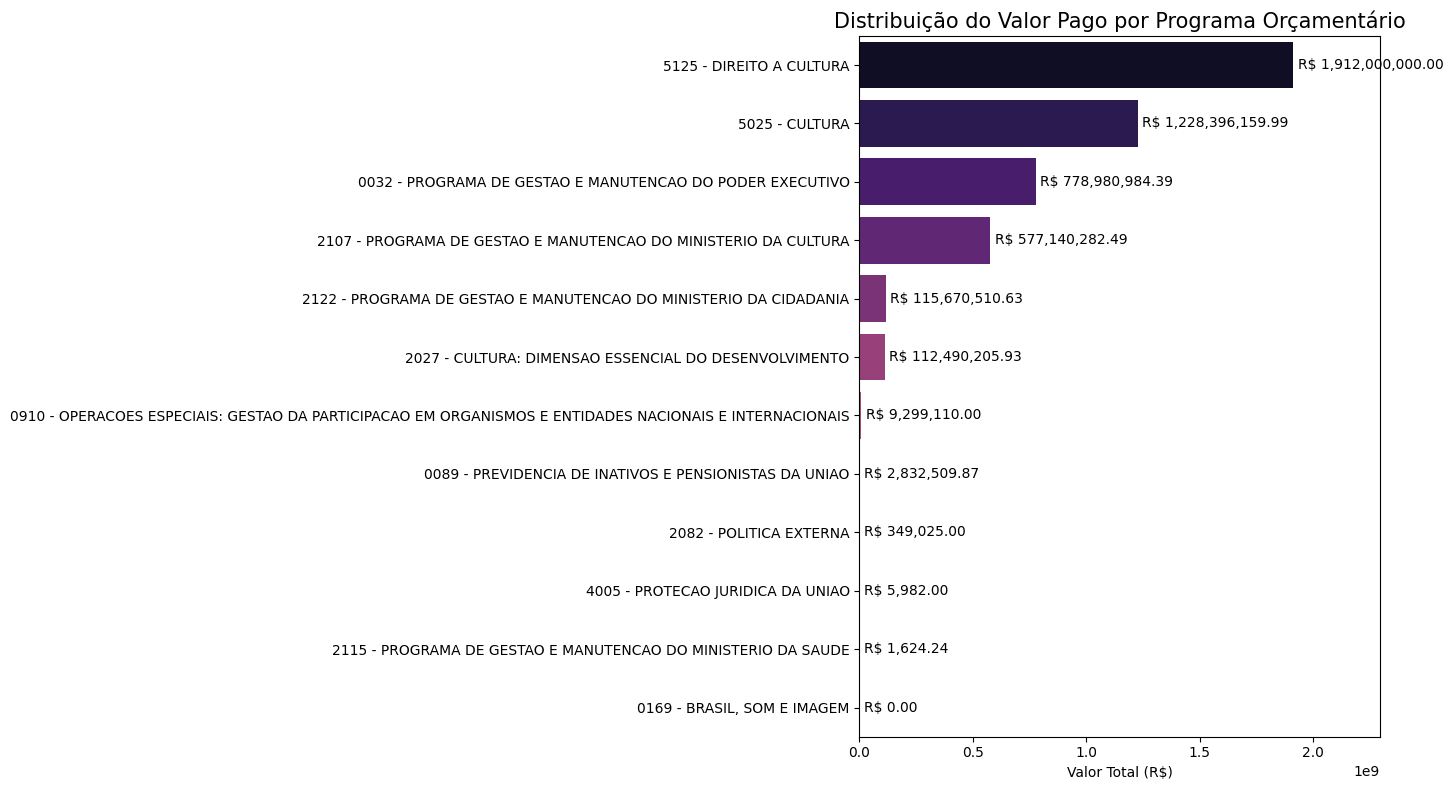

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar e ordenar os dados
df_plot = (
    df_programa
    .groupby("programa_orcamentario")["Valor Pago"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Criar o gráfico
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_plot,
    x="Valor Pago",
    y="programa_orcamentario",
    palette="magma"
)

# 3. Adicionar os valores nas barras (forma mais confiável)
for p in ax.patches:
    valor = p.get_width()
    ax.text(
        valor + df_plot["Valor Pago"].max() * 0.01,  # espaço à direita
        p.get_y() + p.get_height() / 2,
        f'R$ {valor:,.2f}',
        va='center'
    )

# 4. Ajustes finais
plt.title("Distribuição do Valor Pago por Programa Orçamentário", fontsize=15)
plt.xlabel("Valor Total (R$)")
plt.ylabel("")
plt.xlim(0, df_plot["Valor Pago"].max() * 1.2)

plt.tight_layout()
plt.show()

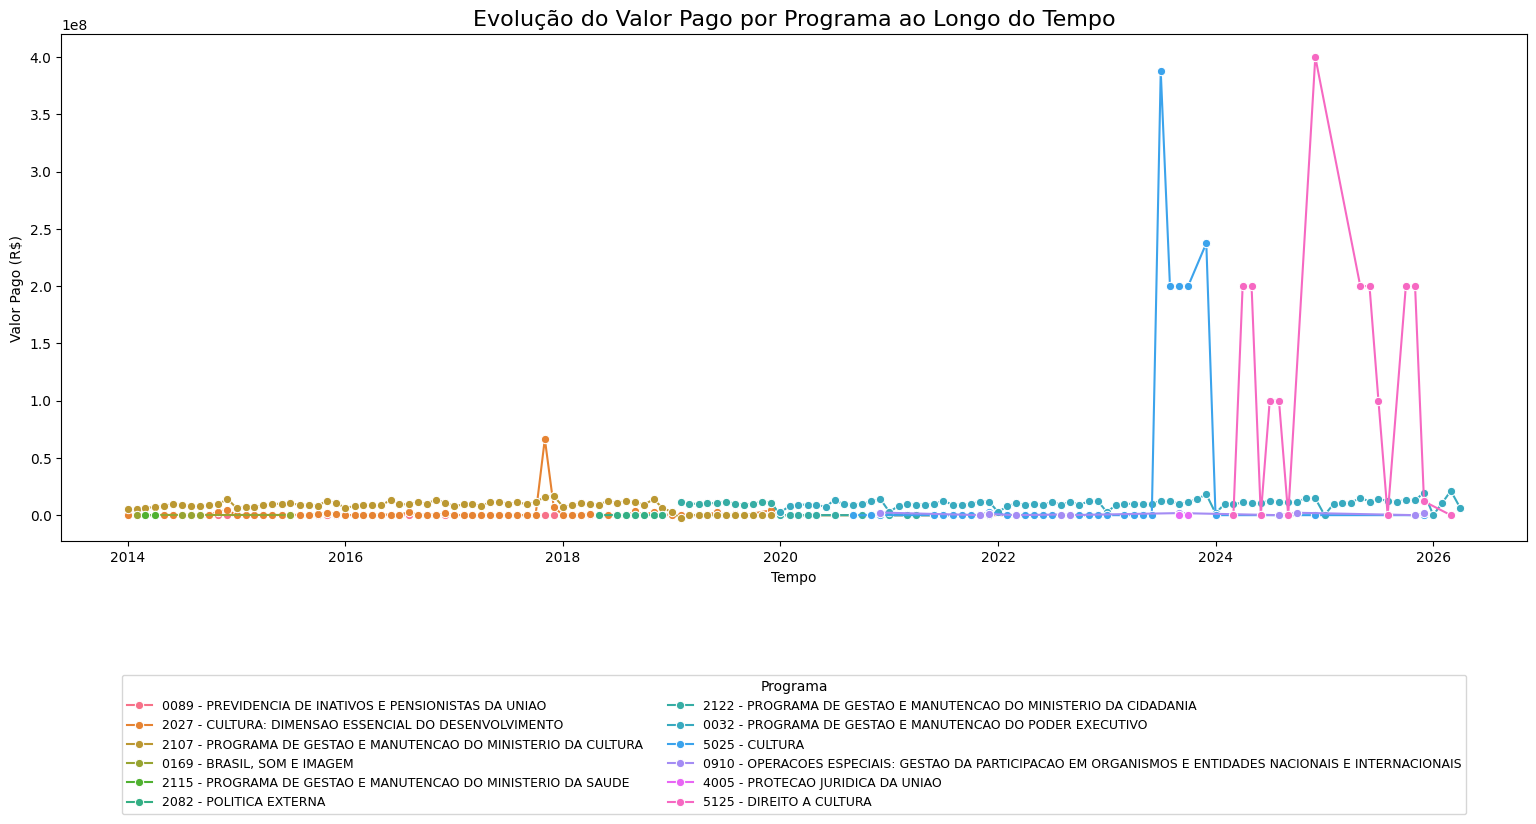

In [ ]:
df_time = (
    df_programa
    .groupby(["mes_ano", "programa_orcamentario"])["Valor Pago"]
    .sum()
    .reset_index()
)

# Criar gráfico maior
plt.figure(figsize=(16, 10))

ax = sns.lineplot(
    data=df_time,
    x="mes_ano",
    y="Valor Pago",
    hue="programa_orcamentario",
    marker="o"
)

# Títulos
plt.title("Evolução do Valor Pago por Programa ao Longo do Tempo", fontsize=16)
plt.xlabel("Tempo")
plt.ylabel("Valor Pago (R$)")

# 🔥 LEGENDA EMBAIXO
plt.legend(
    title="Programa",
    bbox_to_anchor=(0.5, -0.25),  # posição abaixo
    loc='upper center',
    ncol=2,  # divide em colunas (ajusta se quiser)
    fontsize=9
)

# Ajustar espaço pra não cortar legenda
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()

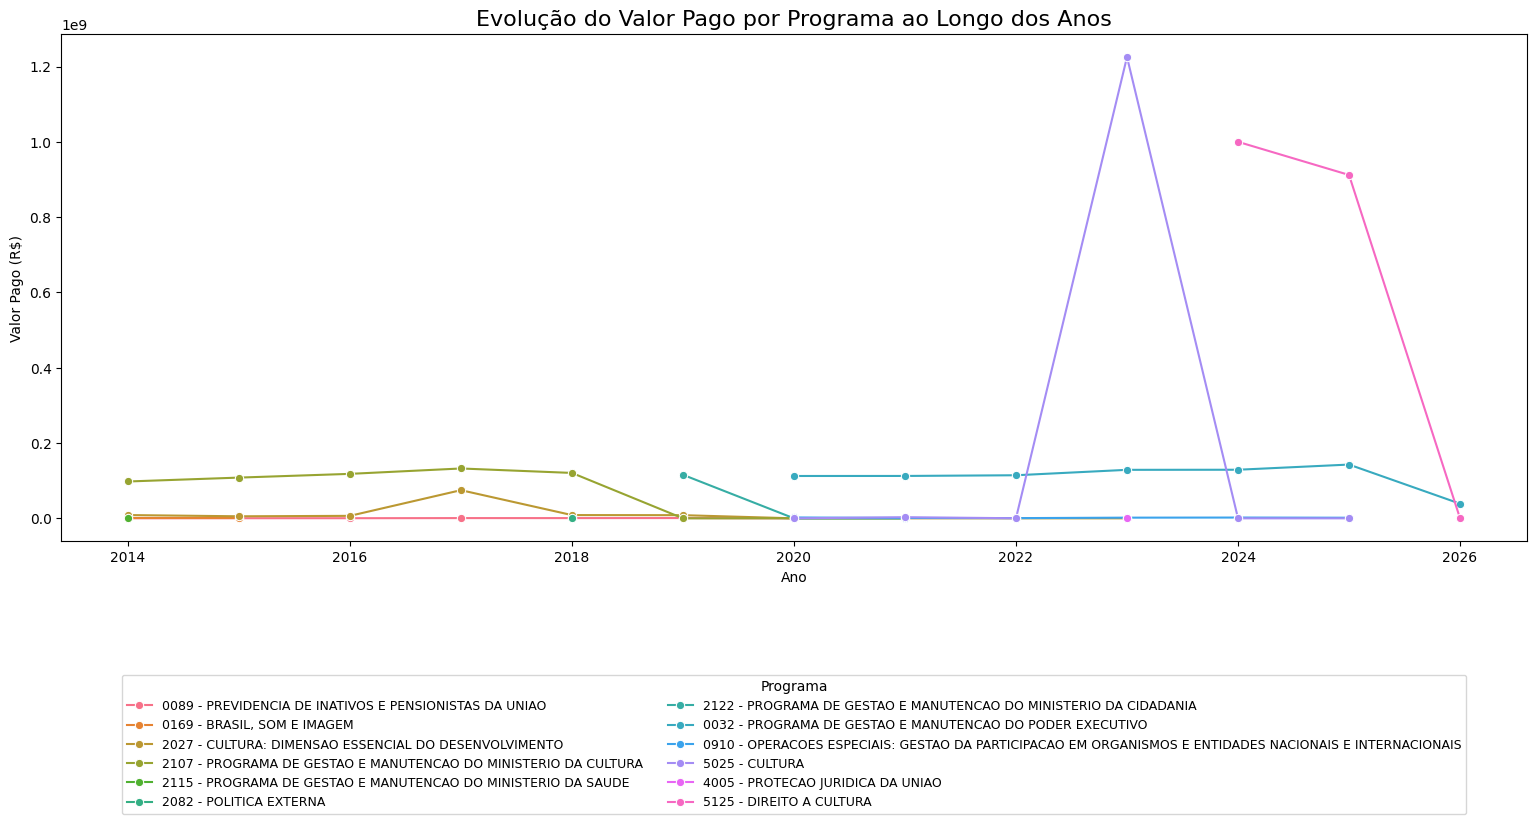

In [ ]:


# 🔥 Criar coluna de ANO
df_programa["ano"] = df_programa["mes_ano"].dt.year

# Agrupar por ANO
df_time = (
    df_programa
    .groupby(["ano", "programa_orcamentario"])["Valor Pago"]
    .sum()
    .reset_index()
)

# Criar gráfico
plt.figure(figsize=(16, 10))

ax = sns.lineplot(
    data=df_time,
    x="ano",
    y="Valor Pago",
    hue="programa_orcamentario",
    marker="o"
)

# Títulos
plt.title("Evolução do Valor Pago por Programa ao Longo dos Anos", fontsize=16)
plt.xlabel("Ano")
plt.ylabel("Valor Pago (R$)")

# Legenda embaixo
plt.legend(
    title="Programa",
    bbox_to_anchor=(0.5, -0.25),
    loc='upper center',
    ncol=2,
    fontsize=9
)

# Ajuste de layout
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()